# 🥗 Advanced Nutrition-Based User Recommendation System
### For Obese & Overweight Individuals — UCI Obesity Levels Dataset

**Dataset:** UCI ML Repository — *Estimation of Obesity Levels Based on Eating Habits and Physical Condition*  
**Source:** https://archive.ics.uci.edu/dataset/544  
**Records:** 2,111 individuals | **Features:** 17 attributes  

---

### What this system does:
Given a user's eating habits, physical activity, BMI, and lifestyle info —  
it recommends a **personalised nutrition & lifestyle plan** by:

1. **Classifying** the user's obesity level (Type I / II / III / Overweight etc.)
2. **Finding similar users** (collaborative filtering via KNN)
3. **Generating diet recommendations** based on BMI + eating habits (content-based)
4. **Hybrid scoring** — blend of both approaches
5. **Full evaluation** — Accuracy, F1, Precision, Recall, Confusion Matrix

**Libraries:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `ucimlrepo` — no PyTorch/Surprise needed.

## 1. Install & Import

In [1]:
!pip install ucimlrepo pandas numpy scikit-learn matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
SEED = 42
np.random.seed(SEED)
print('✅ All libraries loaded!')

✅ All libraries loaded!


## 2. Load the UCI Obesity Dataset

In [3]:
print('📥 Fetching UCI Obesity Levels dataset (ID=544)...')
repo = fetch_ucirepo(id=544)
X_raw = repo.data.features
y_raw = repo.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df.columns = [
    'Gender','Age','Height','Weight',
    'FamilyHistory',        # family history of obesity
    'FAVC',                 # frequent high caloric food
    'FCVC',                 # vegetable consumption frequency
    'NCP',                  # number of main meals
    'CAEC',                 # snacking between meals
    'SMOKE',
    'CH2O',                 # daily water intake
    'SCC',                  # calorie monitoring
    'FAF',                  # physical activity frequency
    'TUE',                  # tech device usage time
    'CALC',                 # alcohol consumption
    'MTRANS',               # transport mode
    'ObesityLevel'          # TARGET
]

print(f'Shape: {df.shape}')
print(f'Obesity levels:\n{df.ObesityLevel.value_counts()}')
df.head()

📥 Fetching UCI Obesity Levels dataset (ID=544)...
Shape: (2111, 17)
Obesity levels:
ObesityLevel
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


,Gender,Age,Height,Weight,FamilyHistory,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,ObesityLevel
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Exploratory Data Analysis

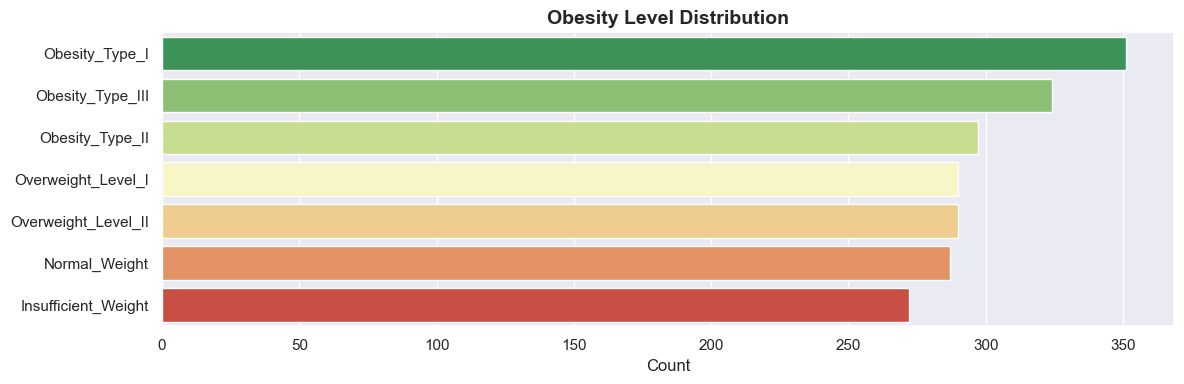

In [4]:
# Obesity level distribution
plt.figure(figsize=(12, 4))
order = df['ObesityLevel'].value_counts().index
palette = sns.color_palette('RdYlGn_r', len(order))
sns.countplot(data=df, y='ObesityLevel', order=order, palette=palette, edgecolor='white')
plt.title('Obesity Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count'); plt.ylabel('')
plt.tight_layout(); plt.show()

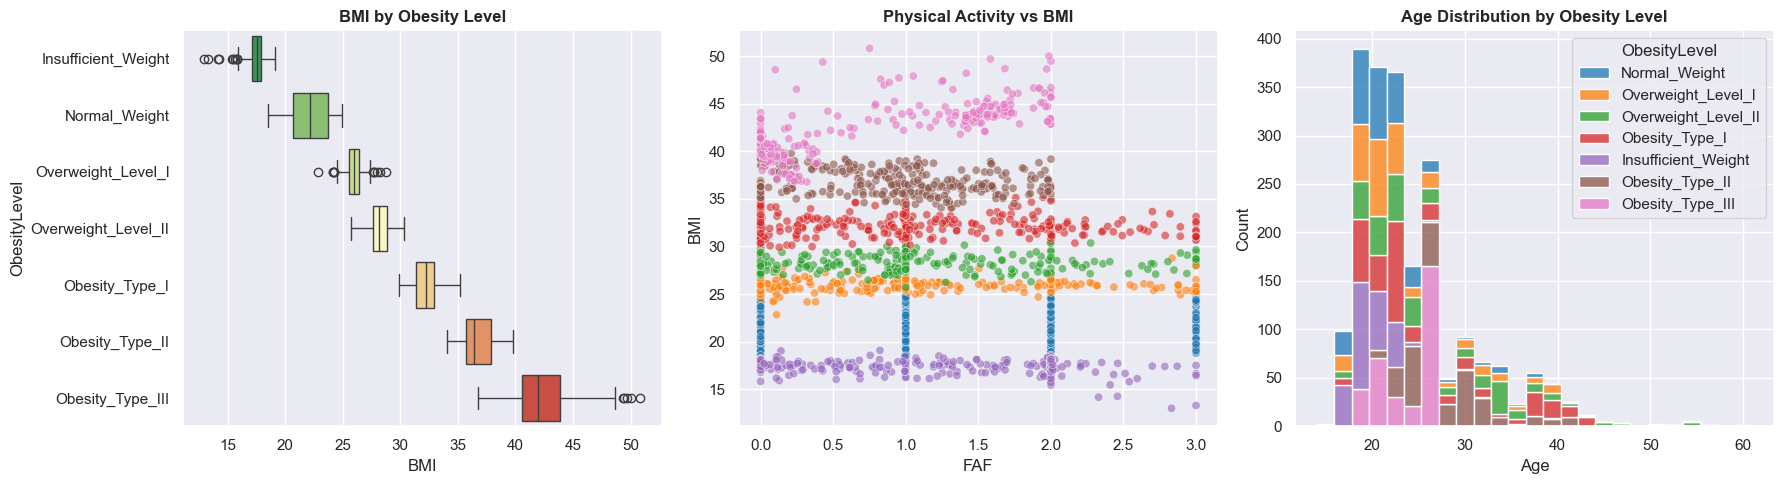

In [5]:
# Compute BMI
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BMI by obesity level
bmi_order = df.groupby('ObesityLevel')['BMI'].median().sort_values().index
sns.boxplot(data=df, x='BMI', y='ObesityLevel', order=bmi_order,
            palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('BMI by Obesity Level', fontsize=12, fontweight='bold')

# Physical activity vs BMI
sns.scatterplot(data=df, x='FAF', y='BMI', hue='ObesityLevel',
                palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set_title('Physical Activity vs BMI', fontsize=12, fontweight='bold')
axes[1].get_legend().remove()

# Age distribution
sns.histplot(data=df, x='Age', hue='ObesityLevel', multiple='stack',
             bins=25, palette='tab10', ax=axes[2])
axes[2].set_title('Age Distribution by Obesity Level', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

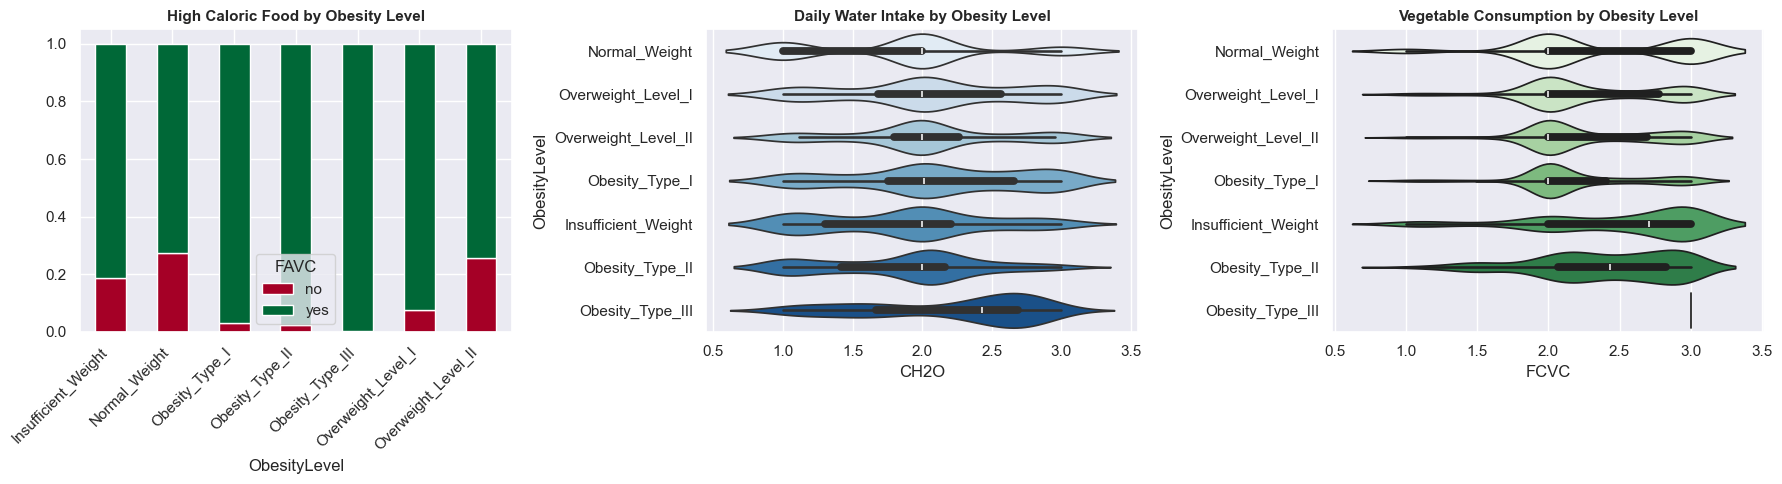

In [6]:
# Eating habits analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# High caloric food
favc_pct = df.groupby(['ObesityLevel','FAVC']).size().unstack(fill_value=0)
favc_pct.div(favc_pct.sum(axis=1), axis=0).plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn', edgecolor='white')
axes[0].set_title('High Caloric Food by Obesity Level', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Water consumption
sns.violinplot(data=df, x='CH2O', y='ObesityLevel', palette='Blues', ax=axes[1])
axes[1].set_title('Daily Water Intake by Obesity Level', fontsize=11, fontweight='bold')

# Vegetable consumption
sns.violinplot(data=df, x='FCVC', y='ObesityLevel', palette='Greens', ax=axes[2])
axes[2].set_title('Vegetable Consumption by Obesity Level', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()

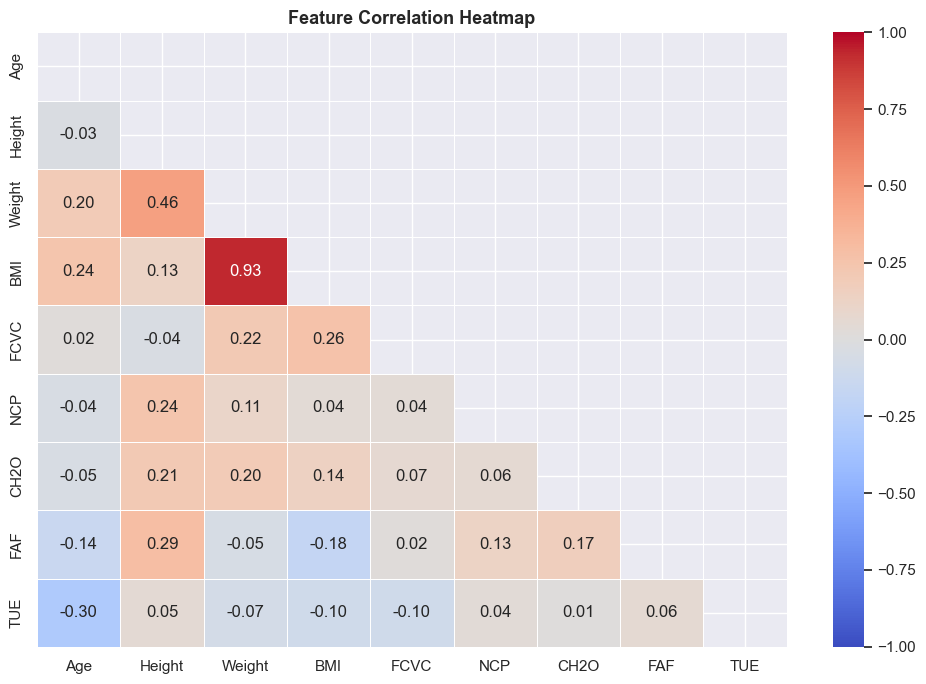

In [7]:
# Correlation heatmap (numeric features)
num_cols = ['Age','Height','Weight','BMI','FCVC','NCP','CH2O','FAF','TUE']
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Preprocessing & Feature Engineering

In [8]:
df_enc = df.copy()

# ---- Encode categorical columns ----
cat_cols = ['Gender','FamilyHistory','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

# ---- Encode target ----
target_le = LabelEncoder()
df_enc['ObesityLevel_enc'] = target_le.fit_transform(df_enc['ObesityLevel'])
class_names = target_le.classes_
print('Classes:', list(class_names))

# ---- Additional features ----
df_enc['BMI']            = df_enc['Weight'] / (df_enc['Height'] ** 2)
df_enc['ActivityScore']  = df_enc['FAF'] * df_enc['CH2O']          # hydration × activity
df_enc['DietScore']      = df_enc['FCVC'] * df_enc['NCP'] - df_enc['FAVC']  # veggie×meals - junkfood
df_enc['HealthIndex']    = df_enc['FAF'] + df_enc['FCVC'] + df_enc['CH2O'] - df_enc['TUE']

feature_cols = [
    'Gender','Age','Height','Weight','BMI',
    'FamilyHistory','FAVC','FCVC','NCP','CAEC',
    'SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS',
    'ActivityScore','DietScore','HealthIndex'
]

X = df_enc[feature_cols].values
y = df_enc['ObesityLevel_enc'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'\nFeatures: {X.shape[1]} | Train: {len(X_train):,} | Test: {len(X_test):,}')

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

Features: 20 | Train: 1,688 | Test: 423


## 5. Model 1 — Obesity Level Classifier (Multi-Model Comparison)

In [9]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=SEED),
    'KNN Classifier'      : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=12, random_state=SEED),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=SEED),
    'MLP Neural Net'      : MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=300,
                                          early_stopping=True, random_state=SEED)
}

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Model':<25} | {'CV Accuracy':>12} | {'Std':>6}")
print('-'*50)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<25} | {scores.mean():>12.4f} | {scores.std():>6.4f}")

Model                     |  CV Accuracy |    Std
--------------------------------------------------
Logistic Regression       |       0.9090 | 0.0141
KNN Classifier            |       0.8129 | 0.0149
Random Forest             |       0.9915 | 0.0039
Gradient Boosting         |       0.9820 | 0.0055
MLP Neural Net            |       0.9413 | 0.0112


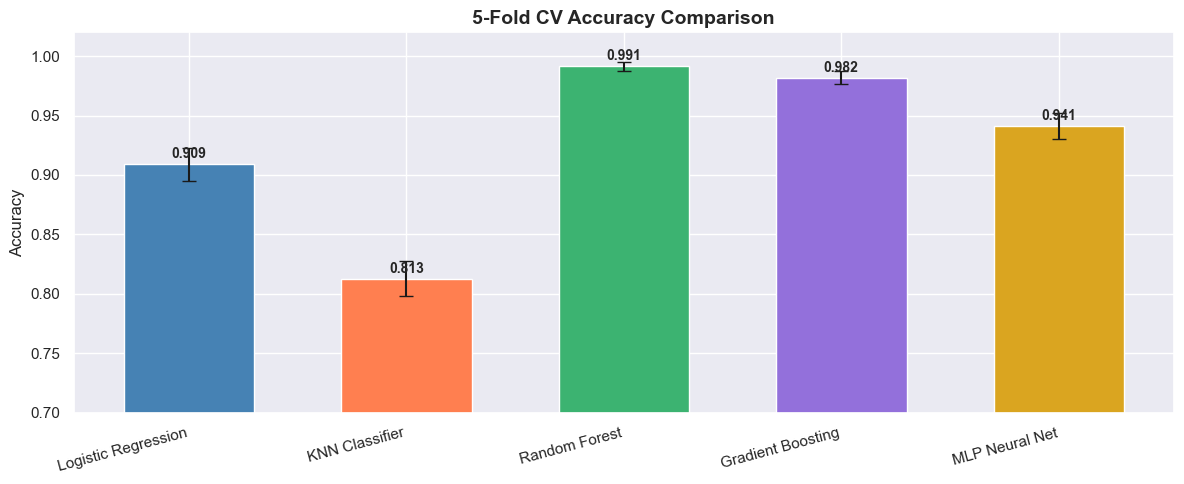

In [10]:
# Visualise CV results
fig, ax = plt.subplots(figsize=(12, 5))
means = [results[m].mean() for m in models]
stds  = [results[m].std()  for m in models]
colors= ['steelblue','coral','mediumseagreen','mediumpurple','goldenrod']
bars  = ax.bar(models.keys(), means, yerr=stds, capsize=5,
               color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('5-Fold CV Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0.7, 1.02)
ax.set_xticklabels(models.keys(), rotation=15, ha='right')
plt.tight_layout(); plt.show()

In [11]:
# Train best model (Random Forest / Gradient Boosting)
best_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=SEED)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('=== Best Model: Gradient Boosting ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Macro F1      : {f1_score(y_test, y_pred, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

=== Best Model: Gradient Boosting ===
Test Accuracy : 0.9858
Macro F1      : 0.9855

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       0.97      1.00      0.98        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.95      0.96        58
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



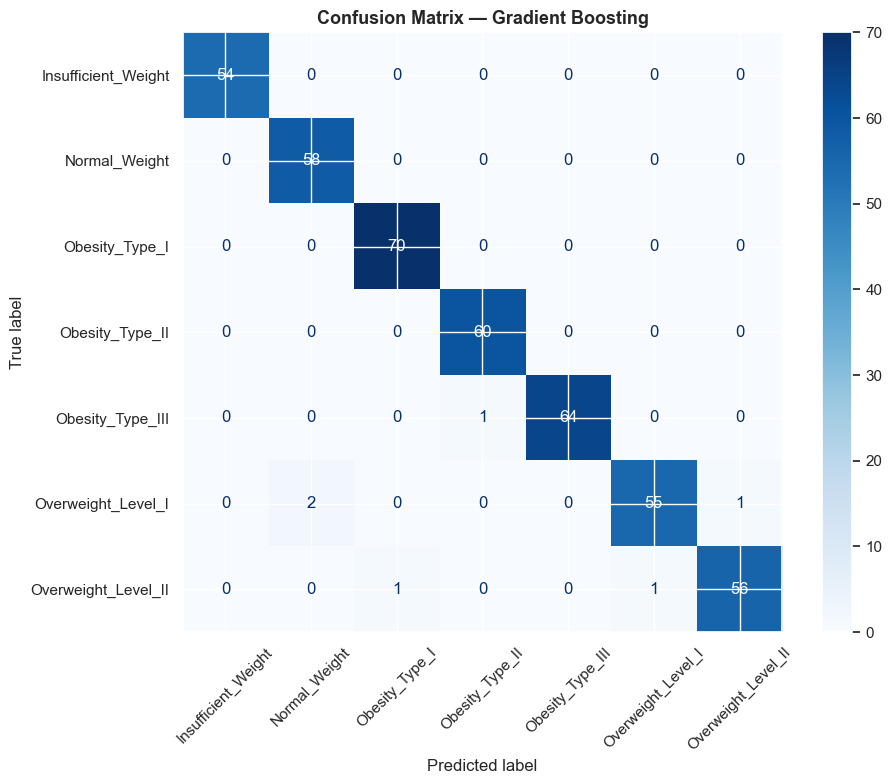

In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

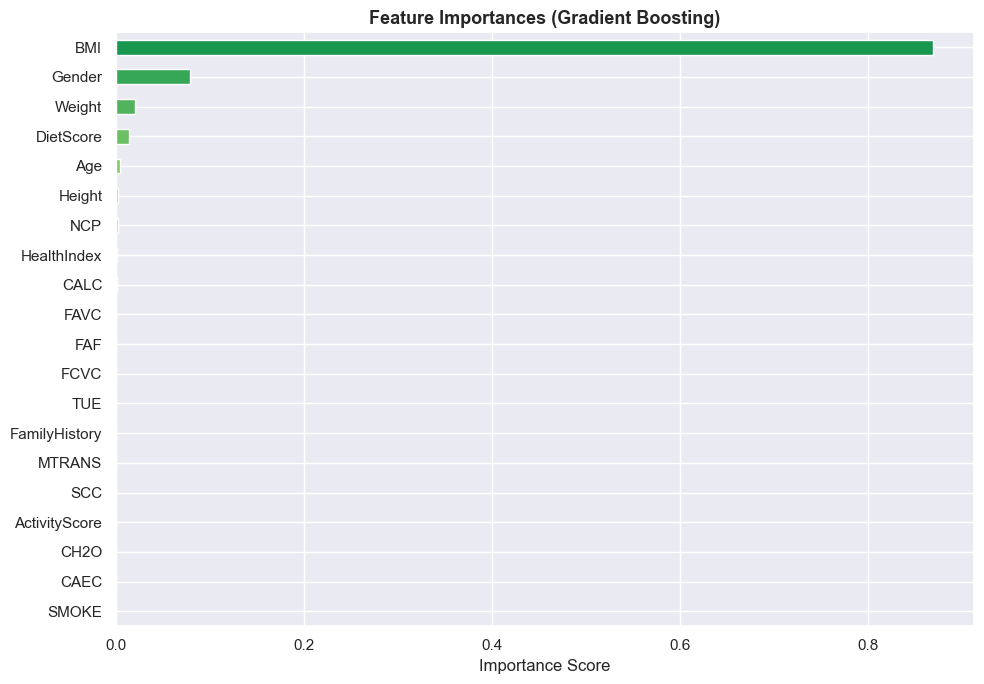

In [13]:
# Feature importance
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances))),
                 edgecolor='white')
plt.title('Feature Importances (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

## 6. Model 2 — KNN Collaborative Filtering
Find the most similar users (by lifestyle & eating profile) and recommend what worked for them.

In [14]:
# Fit KNN on all scaled data
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(X_scaled)

def find_similar_users(user_idx, k=5):
    """Find k users most similar to user at index user_idx."""
    user_vec = X_scaled[user_idx].reshape(1, -1)
    distances, indices = knn.kneighbors(user_vec)
    similar_indices = indices[0][1:]  # exclude self
    similar_distances = distances[0][1:]
    result = df_enc.iloc[similar_indices][['Age','BMI','FAF','FCVC','CH2O','ObesityLevel']].copy()
    result['similarity'] = 1 - similar_distances
    return result.reset_index(drop=True)

print('👥 Users most similar to User #0 (an obese person):')
print(f'User #0 Obesity Level: {df_enc.iloc[0]["ObesityLevel"]}')
find_similar_users(0)

👥 Users most similar to User #0 (an obese person):
User #0 Obesity Level: Normal_Weight


,Age,BMI,FAF,FCVC,CH2O,ObesityLevel,similarity
0,21.000000,27.767098,0.000000,2.000000,1.000000,Overweight_Level_II,0.916103
1,20.634694,27.612088,0.095389,2.512719,1.131169,Overweight_Level_II,0.906568
2,22.154854,27.955900,0.328960,2.000000,1.453626,Overweight_Level_II,0.901717
3,19.911246,29.402646,0.678943,2.258795,1.172186,Overweight_Level_II,0.871264
4,20.843363,28.996813,0.954459,2.493448,1.849997,Overweight_Level_II,0.849138


In [21]:
# ============================================================
#   BMI CLASSIFICATION & OBESITY LEVEL CALCULATOR
#   Based on WHO BMI Standards
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ──────────────────────────────────────────────
#  👇 ENTER USER DETAILS HERE
# ──────────────────────────────────────────────
USER_HEIGHT_CM = 170      # height in centimetres
USER_WEIGHT_KG = 110      # weight in kilograms
USER_NAME      = 'User'   # optional label
# ──────────────────────────────────────────────

# WHO BMI Classification Thresholds
BMI_SCALE = [
    # (label,                    min_bmi,  max_bmi,  color,      obesity_key)
    ('Insufficient Weight',        0.0,     18.5,   '#74add1',  'Insufficient_Weight'),
    ('Normal Weight',             18.5,     25.0,   '#a6d96a',  'Normal_Weight'),
    ('Overweight Level I',        25.0,     27.5,   '#fee08b',  'Overweight_Level_I'),
    ('Overweight Level II',       27.5,     30.0,   '#fdae61',  'Overweight_Level_II'),
    ('Obesity Type I',            30.0,     35.0,   '#f46d43',  'Obesity_Type_I'),
    ('Obesity Type II',           35.0,     40.0,   '#d73027',  'Obesity_Type_II'),
    ('Obesity Type III (Morbid)', 40.0,     70.0,   '#a50026',  'Obesity_Type_III'),
]

# ── Compute BMI ──
height_m = USER_HEIGHT_CM / 100
bmi      = USER_WEIGHT_KG / (height_m ** 2)

# ── Classify ──
user_category   = None
user_color      = 'gray'
user_obesity_key= 'Normal_Weight'
for label, lo, hi, color, key in BMI_SCALE:
    if lo <= bmi < hi:
        user_category    = label
        user_color       = color
        user_obesity_key = key
        break

# ── Weight needed for each boundary ──
def bmi_to_weight(bmi_val, height_m):
    return round(bmi_val * (height_m ** 2), 1)

normal_min_kg  = bmi_to_weight(18.5, height_m)
normal_max_kg  = bmi_to_weight(25.0, height_m)
ow1_max_kg     = bmi_to_weight(27.5, height_m)
ow2_max_kg     = bmi_to_weight(30.0, height_m)
ob1_max_kg     = bmi_to_weight(35.0, height_m)
ob2_max_kg     = bmi_to_weight(40.0, height_m)

weight_to_normal = round(USER_WEIGHT_KG - normal_max_kg, 1)

# ══════════════════════════════════════════════
#  PRINT REPORT
# ══════════════════════════════════════════════
print('=' * 60)
print(f'       🧍 BMI & OBESITY LEVEL REPORT — {USER_NAME}')
print('=' * 60)
print(f'  Height          : {USER_HEIGHT_CM} cm  ({height_m:.2f} m)')
print(f'  Weight          : {USER_WEIGHT_KG} kg')
print(f'  BMI             : {bmi:.2f}')
print(f'  Category        : {user_category}')
print('=' * 60)

print('\n📏 WEIGHT RANGES FOR YOUR HEIGHT:')
print(f"  {'Category':<30} {'BMI Range':<16} {'Weight Range (kg)'}")
print('  ' + '-'*62)
for label, lo, hi, color, key in BMI_SCALE:
    w_lo = bmi_to_weight(lo, height_m)
    w_hi = bmi_to_weight(hi, height_m)
    marker = '  ◀ YOU ARE HERE' if key == user_obesity_key else ''
    hi_disp = f'{hi:.1f}' if hi < 70 else '40+'
    print(f"  {label:<30} {lo:.1f}–{hi_disp:<12}  {w_lo}–{w_hi} kg{marker}")

print('\n🎯 WEIGHT GOALS:')
print(f'  Your current weight     : {USER_WEIGHT_KG} kg')
print(f'  Healthy weight range    : {normal_min_kg} kg – {normal_max_kg} kg  (BMI 18.5–25)')
if weight_to_normal > 0:
    print(f'  Weight to lose for Normal Weight : {weight_to_normal} kg')
elif weight_to_normal < 0:
    print(f'  Weight to gain for Normal Weight : {abs(weight_to_normal)} kg')
else:
    print('  ✅ You are already in the Normal Weight range!')

print('\n📋 OVERWEIGHT & OBESITY THRESHOLDS FOR YOUR HEIGHT:')
print(f'  Overweight Level I  starts at : {bmi_to_weight(25.0, height_m)} kg  (BMI ≥ 25.0)')
print(f'  Overweight Level II starts at : {bmi_to_weight(27.5, height_m)} kg  (BMI ≥ 27.5)')
print(f'  Obesity Type I      starts at : {bmi_to_weight(30.0, height_m)} kg  (BMI ≥ 30.0)')
print(f'  Obesity Type II     starts at : {bmi_to_weight(35.0, height_m)} kg  (BMI ≥ 35.0)')
print(f'  Obesity Type III    starts at : {bmi_to_weight(40.0, height_m)} kg  (BMI ≥ 40.0)')
print('=' * 60)

       🧍 BMI & OBESITY LEVEL REPORT — User
  Height          : 170 cm  (1.70 m)
  Weight          : 110 kg
  BMI             : 38.06
  Category        : Obesity Type II

📏 WEIGHT RANGES FOR YOUR HEIGHT:
  Category                       BMI Range        Weight Range (kg)
  --------------------------------------------------------------
  Insufficient Weight            0.0–18.5          0.0–53.5 kg
  Normal Weight                  18.5–25.0          53.5–72.2 kg
  Overweight Level I             25.0–27.5          72.2–79.5 kg
  Overweight Level II            27.5–30.0          79.5–86.7 kg
  Obesity Type I                 30.0–35.0          86.7–101.1 kg
  Obesity Type II                35.0–40.0          101.1–115.6 kg  ◀ YOU ARE HERE
  Obesity Type III (Morbid)      40.0–40+           115.6–202.3 kg

🎯 WEIGHT GOALS:
  Your current weight     : 110 kg
  Healthy weight range    : 53.5 kg – 72.2 kg  (BMI 18.5–25)
  Weight to lose for Normal Weight : 37.8 kg

📋 OVERWEIGHT & OBESITY THRESHOL

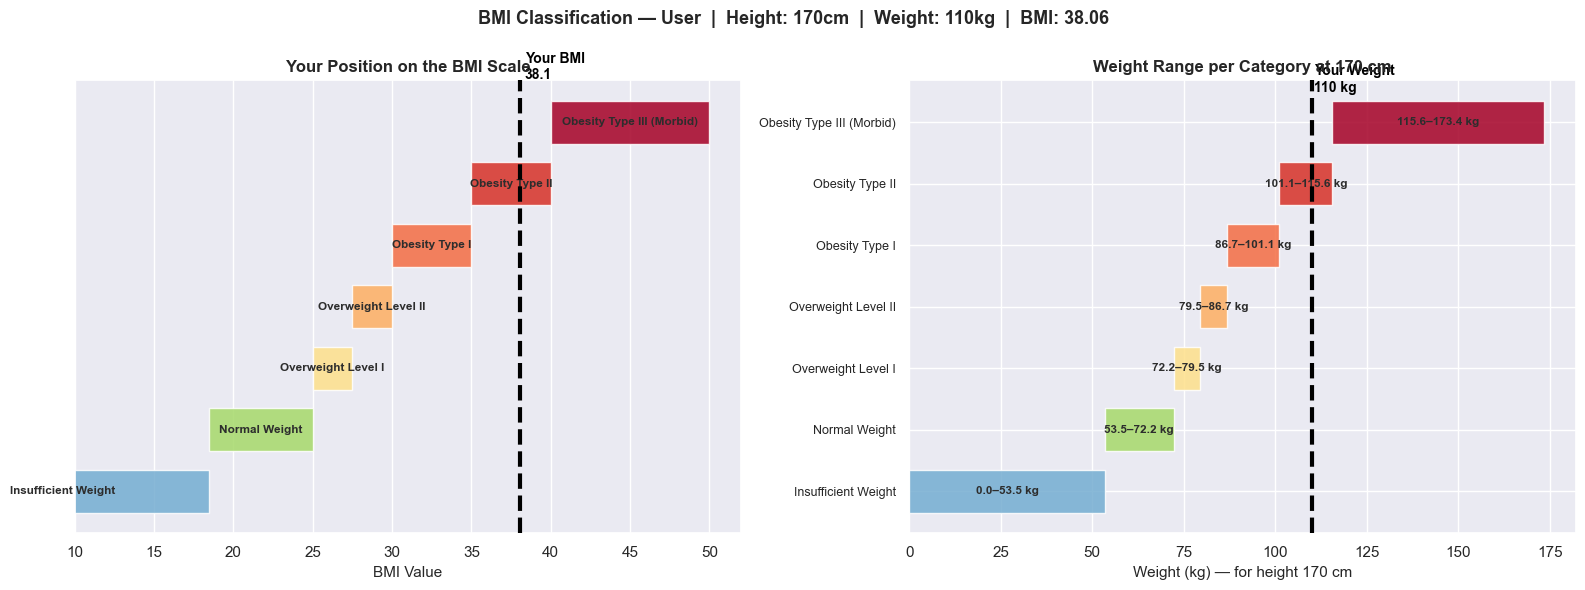


✅ Summary: At 170 cm tall and 110 kg, your BMI is 38.06 → Obesity Type II
   You need to lose 37.8 kg to reach a healthy weight (≤ 72.2 kg).


In [22]:
# ============================================================
#   VISUAL BMI GAUGE CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BMI Classification — {USER_NAME}  |  Height: {USER_HEIGHT_CM}cm  |  Weight: {USER_WEIGHT_KG}kg  |  BMI: {bmi:.2f}',
             fontsize=13, fontweight='bold')

# ── Left: Horizontal BMI scale bar ──
ax1 = axes[0]
y_pos = 0
for label, lo, hi, color, key in BMI_SCALE:
    width = min(hi, 50) - lo
    ax1.barh(y_pos, width, left=lo, color=color, edgecolor='white',
             height=0.7, alpha=0.85)
    ax1.text(lo + width/2, y_pos, label, ha='center', va='center',
             fontsize=8.5, fontweight='bold', color='#2d2d2d')
    y_pos += 1

# Mark user's BMI
ax1.axvline(x=bmi, color='black', linewidth=3, linestyle='--', zorder=5)
ax1.text(bmi + 0.3, y_pos - 0.3, f'Your BMI\n{bmi:.1f}',
         fontsize=10, fontweight='bold', color='black')
ax1.set_xlim(10, 52)
ax1.set_yticks([])
ax1.set_xlabel('BMI Value', fontsize=11)
ax1.set_title('Your Position on the BMI Scale', fontweight='bold')

# ── Right: Weight thresholds bar for user's height ──
ax2 = axes[1]
labels_w, weights_lo, weights_hi, colors_w = [], [], [], []
for label, lo, hi, color, key in BMI_SCALE:
    w_lo = bmi_to_weight(lo, height_m)
    w_hi = bmi_to_weight(min(hi, 60), height_m)
    labels_w.append(label)
    weights_lo.append(w_lo)
    weights_hi.append(w_hi)
    colors_w.append(color)

for i, (label, wlo, whi, color) in enumerate(zip(labels_w, weights_lo, weights_hi, colors_w)):
    ax2.barh(i, whi - wlo, left=wlo, color=color, edgecolor='white', height=0.7, alpha=0.85)
    ax2.text(wlo + (whi-wlo)/2, i, f'{wlo}–{whi} kg',
             ha='center', va='center', fontsize=8.5, fontweight='bold', color='#2d2d2d')

# Mark user's weight
ax2.axvline(x=USER_WEIGHT_KG, color='black', linewidth=3, linestyle='--', zorder=5)
ax2.text(USER_WEIGHT_KG + 0.5, len(BMI_SCALE) - 0.5,
         f'Your Weight\n{USER_WEIGHT_KG} kg',
         fontsize=10, fontweight='bold', color='black')
ax2.set_yticks(range(len(labels_w)))
ax2.set_yticklabels(labels_w, fontsize=9)
ax2.set_xlabel(f'Weight (kg) — for height {USER_HEIGHT_CM} cm', fontsize=11)
ax2.set_title(f'Weight Range per Category at {USER_HEIGHT_CM} cm', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n✅ Summary: At {USER_HEIGHT_CM} cm tall and {USER_WEIGHT_KG} kg, your BMI is {bmi:.2f} → {user_category}')
if weight_to_normal > 0:
    print(f'   You need to lose {weight_to_normal} kg to reach a healthy weight (≤ {normal_max_kg} kg).')

## 7. Nutrition Recommendation Engine
Rule-based diet + lifestyle recommendations mapped to each obesity classification.

In [15]:
NUTRITION_PLANS = {
    'Insufficient_Weight': {
        'calorie_target'   : '2200–2600 kcal/day',
        'macros'           : 'Carbs 50% | Protein 25% | Fat 25%',
        'meal_plan'        : ['Oats with banana & peanut butter',
                              'Brown rice + chicken + avocado',
                              'Greek yogurt with nuts & honey',
                              'Whole wheat pasta with lean meat sauce'],
        'foods_to_increase': ['Whole grains','Lean proteins','Healthy fats','Dairy'],
        'foods_to_avoid'   : ['Empty calorie snacks','Excessive sugar'],
        'hydration'        : '2.0 litres/day',
        'exercise'         : 'Light strength training 3x/week, 20 min walks',
        'priority'         : 'Increase caloric intake with nutritious foods'
    },
    'Normal_Weight': {
        'calorie_target'   : '1800–2200 kcal/day',
        'macros'           : 'Carbs 45% | Protein 25% | Fat 30%',
        'meal_plan'        : ['Whole grain toast + eggs + fruit',
                              'Grilled fish + quinoa + steamed vegetables',
                              'Mixed salad with olive oil dressing',
                              'Lentil soup + whole grain bread'],
        'foods_to_increase': ['Vegetables','Fruits','Whole grains','Lean protein'],
        'foods_to_avoid'   : ['Processed foods','Excessive sugar','Trans fats'],
        'hydration'        : '2.0–2.5 litres/day',
        'exercise'         : 'Mixed cardio + strength 4x/week',
        'priority'         : 'Maintain healthy weight and balanced diet'
    },
    'Overweight_Level_I': {
        'calorie_target'   : '1600–1900 kcal/day',
        'macros'           : 'Carbs 40% | Protein 30% | Fat 30%',
        'meal_plan'        : ['Vegetable omelette + whole grain toast',
                              'Grilled chicken salad with lemon dressing',
                              'Steamed vegetables + baked salmon',
                              'Legume-based stew + small brown rice portion'],
        'foods_to_increase': ['Non-starchy vegetables','Lean protein','Fibre-rich foods','Water'],
        'foods_to_avoid'   : ['High-calorie snacks','Refined carbs','Sugary drinks','Fried foods'],
        'hydration'        : '2.5 litres/day',
        'exercise'         : 'Cardio 4x/week (30 min), light strength training',
        'priority'         : 'Moderate calorie reduction, increase fibre & protein'
    },
    'Overweight_Level_II': {
        'calorie_target'   : '1400–1700 kcal/day',
        'macros'           : 'Carbs 35% | Protein 35% | Fat 30%',
        'meal_plan'        : ['Low-fat yogurt + berries + seeds',
                              'Tuna salad wrap with whole wheat tortilla',
                              'Vegetable stir-fry + tofu',
                              'Chickpea curry + small chapati'],
        'foods_to_increase': ['High-fibre vegetables','Lean protein','Low-GI foods'],
        'foods_to_avoid'   : ['White bread','Fast food','Alcohol','Processed meats'],
        'hydration'        : '2.5–3.0 litres/day',
        'exercise'         : 'Brisk walking 45 min/day, swimming, cycling',
        'priority'         : 'Consistent calorie deficit, eliminate processed foods'
    },
    'Obesity_Type_I': {
        'calorie_target'   : '1200–1500 kcal/day',
        'macros'           : 'Carbs 30% | Protein 40% | Fat 30%',
        'meal_plan'        : ['Protein smoothie with spinach & chia seeds',
                              'Grilled turkey breast + roasted vegetables',
                              'Large mixed salad + boiled eggs',
                              'Lentil soup (no bread)'],
        'foods_to_increase': ['Leafy greens','High-protein foods','Fibre','Water'],
        'foods_to_avoid'   : ['Sugar','Alcohol','Refined carbs','High-fat dairy','Fast food'],
        'hydration'        : '3.0 litres/day',
        'exercise'         : 'Low-impact cardio daily (45 min), consult physiotherapist',
        'priority'         : '⚠️ Consult dietitian. Strict calorie control + high protein'
    },
    'Obesity_Type_II': {
        'calorie_target'   : '1100–1400 kcal/day (medical supervision recommended)',
        'macros'           : 'Carbs 25% | Protein 45% | Fat 30%',
        'meal_plan'        : ['Egg whites + steamed spinach',
                              'Grilled fish + large salad (no dressing)',
                              'Vegetable soup (low sodium)',
                              'Cottage cheese + cucumber'],
        'foods_to_increase': ['Non-starchy vegetables','Lean protein','Green tea'],
        'foods_to_avoid'   : ['All sugar','Alcohol','Starchy foods','Fatty meats','Dairy'],
        'hydration'        : '3.0–3.5 litres/day',
        'exercise'         : 'Chair exercises, water aerobics, supervised walking program',
        'priority'         : '🚨 Medical supervision required. Structured diet + behavioral therapy'
    },
    'Obesity_Type_III': {
        'calorie_target'   : '800–1100 kcal/day (strict medical supervision only)',
        'macros'           : 'Carbs 20% | Protein 50% | Fat 30%',
        'meal_plan'        : ['Protein shake + multivitamin',
                              'Steamed broccoli + grilled chicken (no oil)',
                              'Clear vegetable broth',
                              'Cucumber slices + boiled egg white'],
        'foods_to_increase': ['Lean proteins','Fibre','Water','Vitamins/minerals'],
        'foods_to_avoid'   : ['All processed food','Carbs','Alcohol','Sugar','Oils'],
        'hydration'        : '3.5+ litres/day',
        'exercise'         : 'Bed/chair exercises only. Supervised by medical team.',
        'priority'         : '🚨🚨 URGENT: Requires bariatric specialist, nutritionist & psychologist'
    }
}

print('✅ Nutrition plans defined for all 7 obesity levels!')

✅ Nutrition plans defined for all 7 obesity levels!


## 8. Hybrid Recommendation System

In [16]:
class NutritionRecommender:
    """
    Hybrid nutrition recommendation system for obese users.
    
    Combines:
    1. ML Classification  — predict obesity level
    2. KNN Collaborative  — find similar users
    3. Content-Based      — match to nutrition plan by BMI + habits
    """
    def __init__(self, classifier, knn_model, scaler, feature_cols,
                 target_le, X_scaled, df_enc, nutrition_plans):
        self.clf       = classifier
        self.knn       = knn_model
        self.scaler    = scaler
        self.feat_cols = feature_cols
        self.target_le = target_le
        self.X_scaled  = X_scaled
        self.df_enc    = df_enc
        self.plans     = nutrition_plans

    def _preprocess_user(self, user_dict):
        """Convert raw user input dict → scaled feature vector."""
        row = pd.DataFrame([user_dict])
        # Encode categoricals
        for col, le in label_encoders.items():
            if col in row.columns:
                try:
                    row[col] = le.transform(row[col].astype(str))
                except ValueError:
                    row[col] = 0
        # Derived features
        row['BMI']          = row['Weight'] / (row['Height'] ** 2)
        row['ActivityScore']= row['FAF'] * row['CH2O']
        row['DietScore']    = row['FCVC'] * row['NCP'] - row['FAVC']
        row['HealthIndex']  = row['FAF'] + row['FCVC'] + row['CH2O'] - row['TUE']
        # Ensure all feature cols exist
        for c in self.feat_cols:
            if c not in row.columns:
                row[c] = 0
        vec = row[self.feat_cols].values
        return self.scaler.transform(vec)

    def predict_obesity_level(self, user_vec):
        pred_idx  = self.clf.predict(user_vec)[0]
        proba     = self.clf.predict_proba(user_vec)[0]
        label     = self.target_le.classes_[pred_idx]
        conf      = proba[pred_idx]
        return label, conf, dict(zip(self.target_le.classes_, proba))

    def find_similar_users(self, user_vec, k=5):
        dists, idxs = self.knn.kneighbors(user_vec)
        sim_df = self.df_enc.iloc[idxs[0]][['Age','BMI','FAF','FCVC','CH2O','ObesityLevel']].copy()
        sim_df['similarity'] = (1 - dists[0]).round(4)
        return sim_df.reset_index(drop=True)

    def content_score(self, user_dict, obesity_level):
        """Adjust plan priority based on user's specific bad habits."""
        flags = []
        if str(user_dict.get('FAVC','')).lower() in ['yes','1']:
            flags.append('⚠️  High caloric food consumption detected')
        if float(user_dict.get('CH2O', 2)) < 2:
            flags.append('💧 Low water intake — increase hydration urgently')
        if float(user_dict.get('FAF', 1)) < 1:
            flags.append('🏃 Very low physical activity — start with 20 min walks')
        if str(user_dict.get('SMOKE','')).lower() in ['yes','1']:
            flags.append('🚭 Smoking detected — cessation recommended for weight loss')
        if str(user_dict.get('CALC','')).lower() in ['frequently','always']:
            flags.append('🍺 Frequent alcohol consumption — significant empty calories')
        if float(user_dict.get('TUE', 1)) > 2:
            flags.append('📱 High tech device usage — sedentary risk, reduce screen time')
        return flags

    def recommend(self, user_dict):
        """Full recommendation pipeline for a new user."""
        user_vec = self._preprocess_user(user_dict)
        bmi      = user_dict['Weight'] / (user_dict['Height'] ** 2)

        # Step 1: Predict obesity level
        obesity_level, confidence, all_proba = self.predict_obesity_level(user_vec)
        plan_key = obesity_level.replace(' ', '_')
        plan     = self.plans.get(plan_key, self.plans['Normal_Weight'])

        # Step 2: Similar users
        similar_users = self.find_similar_users(user_vec)

        # Step 3: Personalised flags
        personal_flags = self.content_score(user_dict, obesity_level)

        # ---- Print full recommendation ----
        print('=' * 65)
        print('       🥗 PERSONALISED NUTRITION RECOMMENDATION REPORT')
        print('=' * 65)
        print(f'  BMI                 : {bmi:.2f}')
        print(f'  Predicted Level     : {obesity_level}')
        print(f'  Model Confidence    : {confidence:.1%}')
        print('=' * 65)

        print(f"\n📋 NUTRITION PLAN — {obesity_level.upper()}")
        print(f"  🎯 Priority        : {plan['priority']}")
        print(f"  🔥 Calorie Target  : {plan['calorie_target']}")
        print(f"  ⚖️  Macros          : {plan['macros']}")
        print(f"  💧 Hydration       : {plan['hydration']}")
        print(f"  🏋️  Exercise        : {plan['exercise']}")

        print("\n  📅 Sample Daily Meal Plan:")
        for i, meal in enumerate(plan['meal_plan'], 1):
            print(f"     Meal {i}: {meal}")

        print("\n  ✅ Foods to INCREASE:")
        for food in plan['foods_to_increase']:
            print(f"     + {food}")

        print("\n  ❌ Foods to AVOID:")
        for food in plan['foods_to_avoid']:
            print(f"     - {food}")

        if personal_flags:
            print("\n  🔎 PERSONALISED ALERTS (based on your habits):")
            for flag in personal_flags:
                print(f"     {flag}")

        print('\n  👥 Most Similar Users (Collaborative Filtering):')
        print(similar_users.to_string(index=False))

        print('\n  📊 Probability Across All Levels:')
        for k, v in sorted(all_proba.items(), key=lambda x: -x[1]):
            bar = '█' * int(v * 30)
            print(f"     {k:<25} {v:.2%}  {bar}")
        print('=' * 65)

        return {
            'obesity_level' : obesity_level,
            'bmi'           : round(bmi, 2),
            'confidence'    : confidence,
            'plan'          : plan,
            'similar_users' : similar_users,
            'flags'         : personal_flags
        }


recommender = NutritionRecommender(
    classifier     = best_model,
    knn_model      = knn,
    scaler         = scaler,
    feature_cols   = feature_cols,
    target_le      = target_le,
    X_scaled       = X_scaled,
    df_enc         = df_enc,
    nutrition_plans= NUTRITION_PLANS
)
print('✅ Nutrition Recommender ready!')

✅ Nutrition Recommender ready!


## 9. Demo — Recommendations for Sample Users

In [17]:
# --- Demo User 1: Obese person with poor habits ---
user_obese = {
    'Gender'       : 'Male',
    'Age'          : 35,
    'Height'       : 1.70,
    'Weight'       : 110,
    'FamilyHistory': 'yes',
    'FAVC'         : 'yes',
    'FCVC'         : 1,       # rarely eats vegetables
    'NCP'          : 3,
    'CAEC'         : 'Always',
    'SMOKE'        : 'no',
    'CH2O'         : 1,       # low water intake
    'SCC'          : 'no',
    'FAF'          : 0,       # no physical activity
    'TUE'          : 3,       # high screen time
    'CALC'         : 'Frequently',
    'MTRANS'       : 'Automobile'
}
result1 = recommender.recommend(user_obese)

       🥗 PERSONALISED NUTRITION RECOMMENDATION REPORT
  BMI                 : 38.06
  Predicted Level     : Obesity_Type_II
  Model Confidence    : 100.0%

📋 NUTRITION PLAN — OBESITY_TYPE_II
  🎯 Priority        : 🚨 Medical supervision required. Structured diet + behavioral therapy
  🔥 Calorie Target  : 1100–1400 kcal/day (medical supervision recommended)
  ⚖️  Macros          : Carbs 25% | Protein 45% | Fat 30%
  💧 Hydration       : 3.0–3.5 litres/day
  🏋️  Exercise        : Chair exercises, water aerobics, supervised walking program

  📅 Sample Daily Meal Plan:
     Meal 1: Egg whites + steamed spinach
     Meal 2: Grilled fish + large salad (no dressing)
     Meal 3: Vegetable soup (low sodium)
     Meal 4: Cottage cheese + cucumber

  ✅ Foods to INCREASE:
     + Non-starchy vegetables
     + Lean protein
     + Green tea

  ❌ Foods to AVOID:
     - All sugar
     - Alcohol
     - Starchy foods
     - Fatty meats
     - Dairy

  🔎 PERSONALISED ALERTS (based on your habits):
     ⚠️  

In [18]:
# --- Demo User 2: Overweight woman with moderate habits ---
user_overweight = {
    'Gender'       : 'Female',
    'Age'          : 28,
    'Height'       : 1.62,
    'Weight'       : 80,
    'FamilyHistory': 'yes',
    'FAVC'         : 'yes',
    'FCVC'         : 2,
    'NCP'          : 3,
    'CAEC'         : 'Sometimes',
    'SMOKE'        : 'no',
    'CH2O'         : 2,
    'SCC'          : 'no',
    'FAF'          : 1,
    'TUE'          : 1,
    'CALC'         : 'Sometimes',
    'MTRANS'       : 'Public_Transportation'
}
result2 = recommender.recommend(user_overweight)

       🥗 PERSONALISED NUTRITION RECOMMENDATION REPORT
  BMI                 : 30.48
  Predicted Level     : Obesity_Type_I
  Model Confidence    : 100.0%

📋 NUTRITION PLAN — OBESITY_TYPE_I
  🎯 Priority        : ⚠️ Consult dietitian. Strict calorie control + high protein
  🔥 Calorie Target  : 1200–1500 kcal/day
  ⚖️  Macros          : Carbs 30% | Protein 40% | Fat 30%
  💧 Hydration       : 3.0 litres/day
  🏋️  Exercise        : Low-impact cardio daily (45 min), consult physiotherapist

  📅 Sample Daily Meal Plan:
     Meal 1: Protein smoothie with spinach & chia seeds
     Meal 2: Grilled turkey breast + roasted vegetables
     Meal 3: Large mixed salad + boiled eggs
     Meal 4: Lentil soup (no bread)

  ✅ Foods to INCREASE:
     + Leafy greens
     + High-protein foods
     + Fibre
     + Water

  ❌ Foods to AVOID:
     - Sugar
     - Alcohol
     - Refined carbs
     - High-fat dairy
     - Fast food

  🔎 PERSONALISED ALERTS (based on your habits):
     ⚠️  High caloric food consumpt

## 10. Visual Recommendation Dashboard

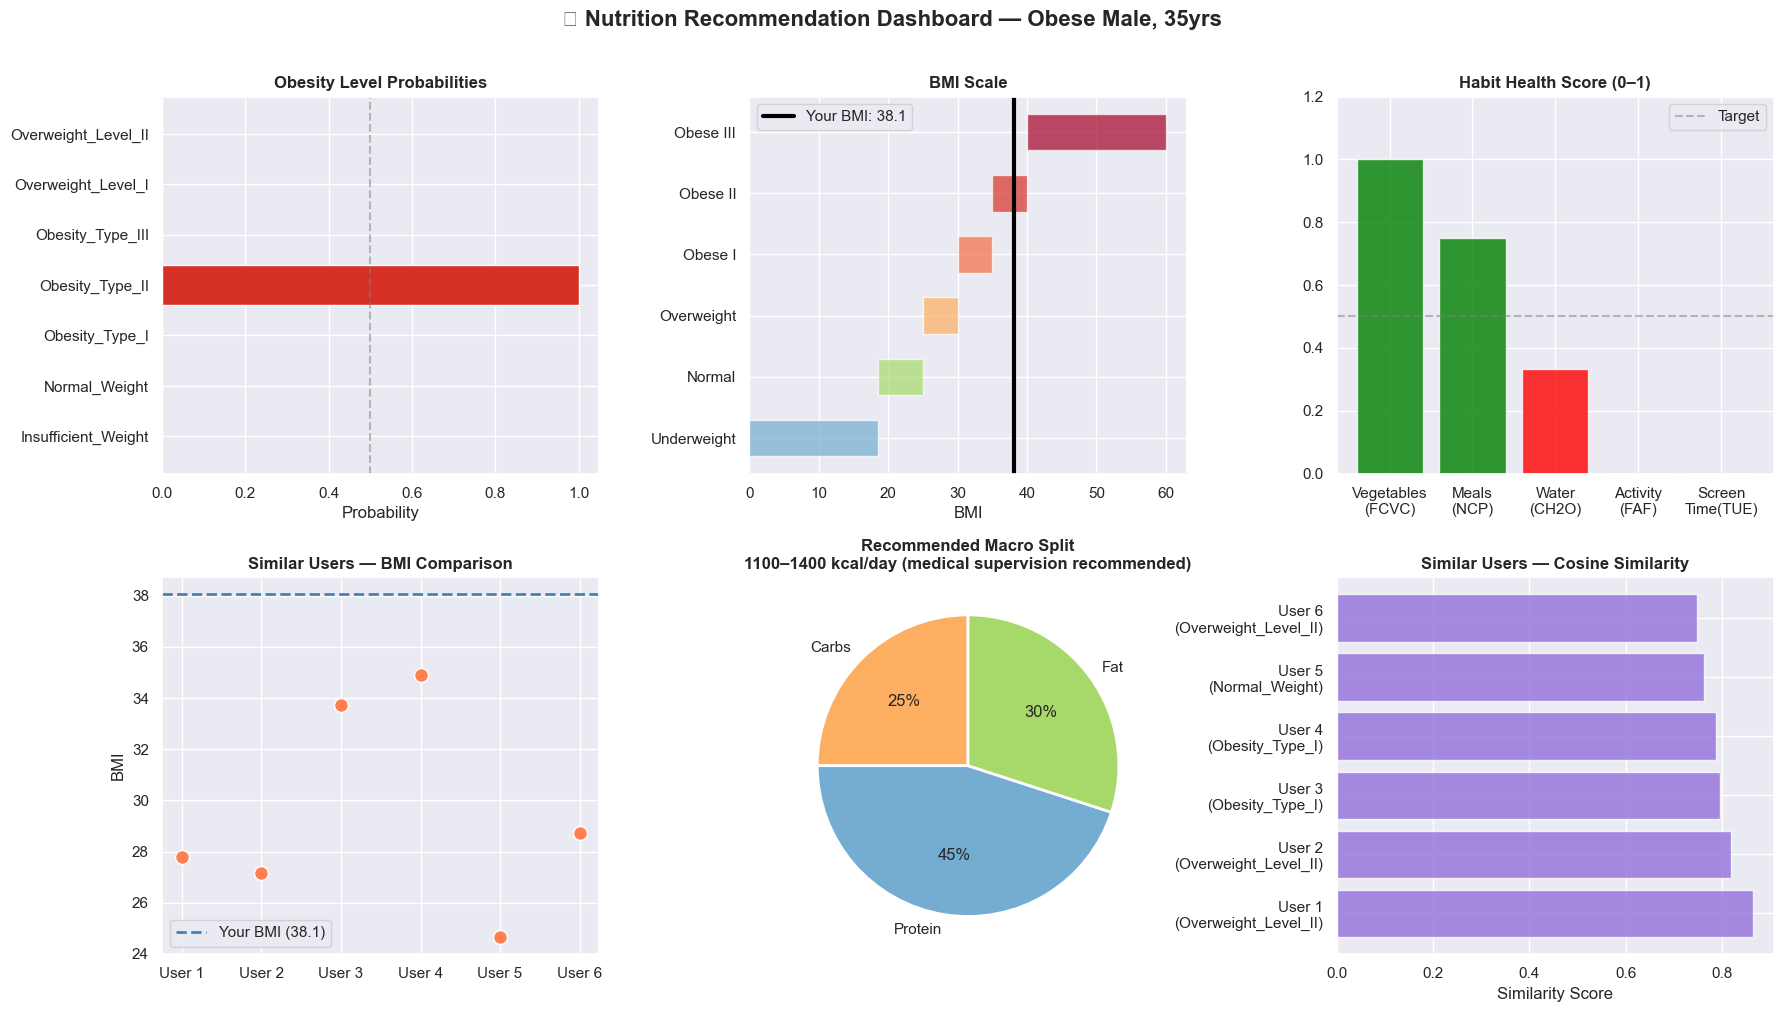

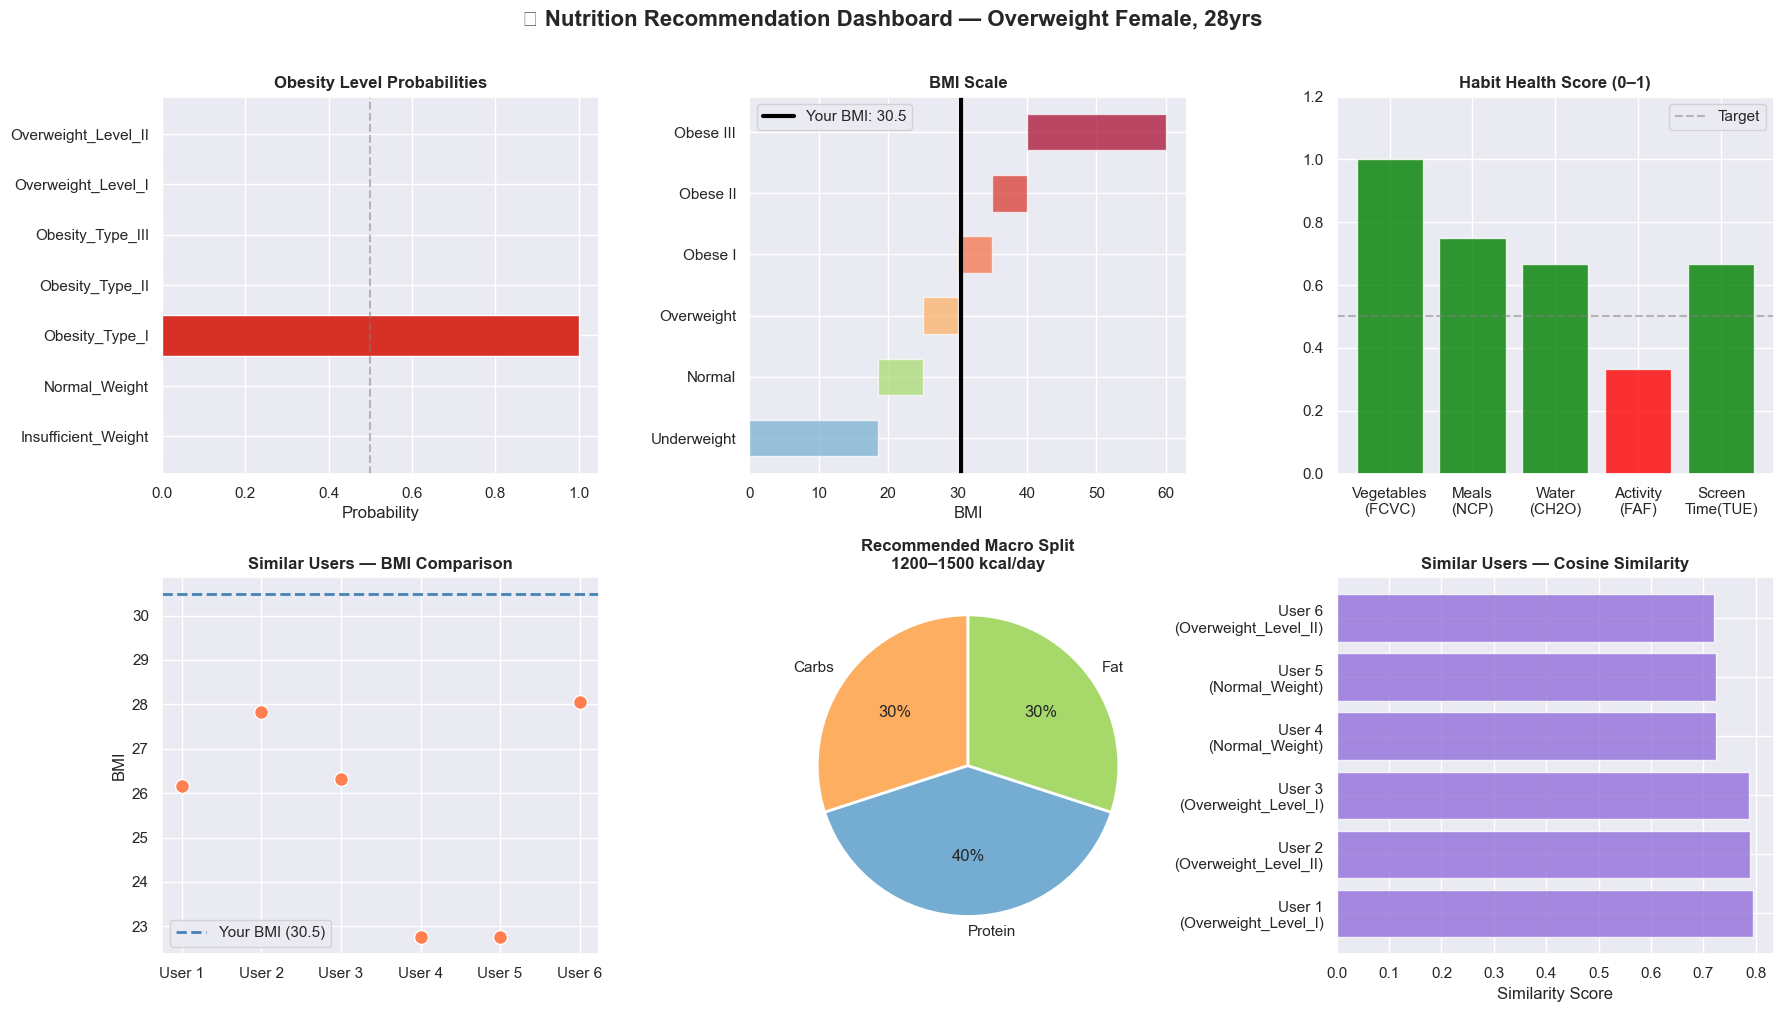

In [19]:
def plot_user_dashboard(result, user_dict, title='User Profile'):
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f'🥗 Nutrition Recommendation Dashboard — {title}',
                 fontsize=16, fontweight='bold', y=1.01)

    # --- 1. Obesity probability chart ---
    ax1 = fig.add_subplot(2, 3, 1)
    levels = list(result['plan'].keys())  # just use plan data
    # rebuild from model
    user_vec = recommender._preprocess_user(user_dict)
    proba    = recommender.clf.predict_proba(user_vec)[0]
    classes  = target_le.classes_
    colors_p = ['#d73027' if c == result['obesity_level'] else '#4575b4' for c in classes]
    ax1.barh(classes, proba, color=colors_p, edgecolor='white')
    ax1.set_title('Obesity Level Probabilities', fontweight='bold')
    ax1.set_xlabel('Probability')
    ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

    # --- 2. BMI gauge ---
    ax2 = fig.add_subplot(2, 3, 2)
    bmi = result['bmi']
    bmi_ranges = [('Underweight',  0,  18.5, '#74add1'),
                  ('Normal',    18.5,  25.0, '#a6d96a'),
                  ('Overweight', 25.0, 30.0, '#fdae61'),
                  ('Obese I',   30.0,  35.0, '#f46d43'),
                  ('Obese II',  35.0,  40.0, '#d73027'),
                  ('Obese III', 40.0,  60.0, '#a50026')]
    for label, lo, hi, color in bmi_ranges:
        ax2.barh(label, hi - lo, left=lo, color=color, alpha=0.7, edgecolor='white', height=0.6)
    ax2.axvline(bmi, color='black', linewidth=3, label=f'Your BMI: {bmi:.1f}')
    ax2.set_title('BMI Scale', fontweight='bold')
    ax2.set_xlabel('BMI'); ax2.legend()

    # --- 3. User habit radar (as bar chart) ---
    ax3 = fig.add_subplot(2, 3, 3)
    habit_labels = ['Vegetables\n(FCVC)', 'Meals\n(NCP)', 'Water\n(CH2O)',
                    'Activity\n(FAF)', 'Screen\nTime(TUE)']
    habit_vals   = [user_dict.get('FCVC',0), user_dict.get('NCP',0)/4,
                    user_dict.get('CH2O',0)/3, user_dict.get('FAF',0)/3,
                    1 - user_dict.get('TUE',0)/3]
    habit_vals   = np.clip(habit_vals, 0, 1)
    bar_colors   = ['green' if v >= 0.5 else 'red' for v in habit_vals]
    ax3.bar(habit_labels, habit_vals, color=bar_colors, edgecolor='white', alpha=0.8)
    ax3.set_title('Habit Health Score (0–1)', fontweight='bold')
    ax3.set_ylim(0, 1.2)
    ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Target')
    ax3.legend()

    # --- 4. Similar users BMI distribution ---
    ax4 = fig.add_subplot(2, 3, 4)
    sim = result['similar_users']
    ax4.scatter(sim.index, sim['BMI'], s=100, c='coral', edgecolors='white', zorder=3)
    ax4.axhline(bmi, color='steelblue', linestyle='--', linewidth=2, label=f'Your BMI ({bmi:.1f})')
    ax4.set_xticks(sim.index)
    ax4.set_xticklabels([f'User {i+1}' for i in sim.index])
    ax4.set_title('Similar Users — BMI Comparison', fontweight='bold')
    ax4.set_ylabel('BMI'); ax4.legend()

    # --- 5. Calorie & macro plan ---
    ax5 = fig.add_subplot(2, 3, 5)
    macro_str = result['plan']['macros']   # e.g. 'Carbs 30% | Protein 40% | Fat 30%'
    parts = [p.strip() for p in macro_str.split('|')]
    macro_labels, macro_vals = [], []
    for p in parts:
        tok = p.split()
        macro_labels.append(tok[0])
        macro_vals.append(int(tok[1].replace('%','')))
    ax5.pie(macro_vals, labels=macro_labels, autopct='%1.0f%%',
            colors=['#fdae61','#74add1','#a6d96a'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
    ax5.set_title(f"Recommended Macro Split\n{result['plan']['calorie_target']}",
                  fontweight='bold')

    # --- 6. Activity + similar users similarity ---
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.barh(sim.index[::-1], sim['similarity'][::-1],
             color='mediumpurple', edgecolor='white', alpha=0.8)
    ax6.set_yticks(sim.index[::-1])
    ax6.set_yticklabels([f'User {i+1}\n({row.ObesityLevel})'
                         for i, row in sim[::-1].iterrows()])
    ax6.set_title('Similar Users — Cosine Similarity', fontweight='bold')
    ax6.set_xlabel('Similarity Score')

    plt.tight_layout()
    plt.show()


plot_user_dashboard(result1, user_obese,      title='Obese Male, 35yrs')
plot_user_dashboard(result2, user_overweight, title='Overweight Female, 28yrs')

## 11. Model Evaluation Summary

,Model,Accuracy,F1 (Macro),F1 (Weighted)
2,Random Forest,0.9929,0.9925,0.9929
3,Gradient Boosting,0.9858,0.9855,0.9858
4,MLP Neural Net,0.9338,0.9319,0.9335
0,Logistic Regression,0.9267,0.9238,0.9259
1,KNN Classifier,0.8109,0.7985,0.8023


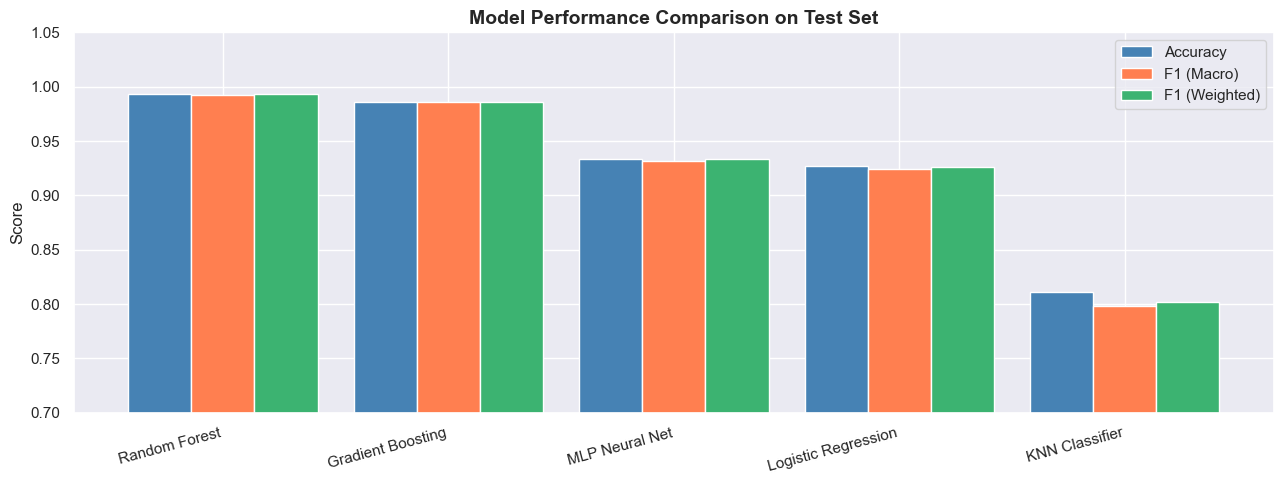

In [20]:
# Full evaluation across all models on held-out test set
eval_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    eval_rows.append({
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_test, preds), 4),
        'F1 (Macro)'  : round(f1_score(y_test, preds, average='macro'), 4),
        'F1 (Weighted)': round(f1_score(y_test, preds, average='weighted'), 4),
    })

eval_df = pd.DataFrame(eval_rows).sort_values('Accuracy', ascending=False)
display(eval_df)

# Plot
x = np.arange(len(eval_df))
width = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, eval_df['Accuracy'],     width, label='Accuracy',      color='steelblue',      edgecolor='white')
ax.bar(x,         eval_df['F1 (Macro)'],   width, label='F1 (Macro)',    color='coral',           edgecolor='white')
ax.bar(x + width, eval_df['F1 (Weighted)'],width, label='F1 (Weighted)', color='mediumseagreen',  edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(eval_df['Model'], rotation=15, ha='right')
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0.7, 1.05)
ax.legend(); plt.tight_layout(); plt.show()

## 12. Summary

| Component | Details |
|---|---|
| **Dataset** | UCI Obesity Levels — 2,111 records, 17 features |
| **Target** | 7 obesity levels (Insufficient Weight → Obesity Type III) |
| **Classifier** | Gradient Boosting (best), + RF, MLP, KNN, LR compared |
| **Collaborative** | KNN Nearest Neighbors — find similar lifestyle profiles |
| **Content-Based** | Rule-based nutrition plans per obesity level |
| **Personalisation** | Habit flags (FAVC, CH2O, FAF, SMOKE, CALC, TUE) |
| **Output** | Calorie target, macros, meal plan, foods to eat/avoid, exercise |
| **Libraries** | pandas, numpy, scikit-learn, matplotlib, seaborn only |

### 🚀 Potential Enhancements
- Integrate real food databases (USDA FoodData Central API) for specific meal suggestions
- Add time-series tracking — log weekly weight/habits and update recommendations
- Use NLP to let users describe their diet in natural language
- Add medication/allergy constraints to filter out incompatible foods
- Deploy as a mobile health app with Flask/FastAPI backend